#Librerías.

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer

#Carga y preprocesamiento de datos.

In [106]:
# Cargar CSV limpio de la Parte 1.
df_model = pd.read_csv("datos_tratados.csv")

In [107]:
df_model.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [108]:
# Eliminar columnas que no aportan al modelo.
df_model.drop(columns=["customerID"], inplace=True)

In [109]:
# Identificar variables categóricas y numéricas.
categoricas = df_model.select_dtypes(include="object").columns.tolist()
categoricas.remove("Churn")
numericas = df_model.select_dtypes(include=np.number).columns.tolist()


In [110]:
# Imputar valores faltantes en numéricas (por seguridad).
imputer = SimpleImputer(strategy="mean")
df_model[numericas] = imputer.fit_transform(df_model[numericas])


In [111]:
# Codificar variables categóricas con One-Hot Encoding.
# Filter `categoricas` to only include columns that still exist in df_model
cols_to_encode = [col for col in categoricas if col in df_model.columns]
df_model = pd.get_dummies(df_model, columns=cols_to_encode, drop_first=True)

In [112]:
# Codificar variable objetivo.
df_model["Churn"] = df_model["Churn"].map({"No":0, "Yes":1})

In [113]:
# Verificar proporción de clases (desbalance).
print("Proporción de Churn:")
print(df_model["Churn"].value_counts(normalize=True))


Proporción de Churn:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


# Normalización de variables numéricas (para modelos sensibles a escala).

In [114]:
# Escalar solo variables numéricas.
scaler = StandardScaler()
df_model[numericas] = scaler.fit_transform(df_model[numericas])

# Análisis de correlación y visualización.

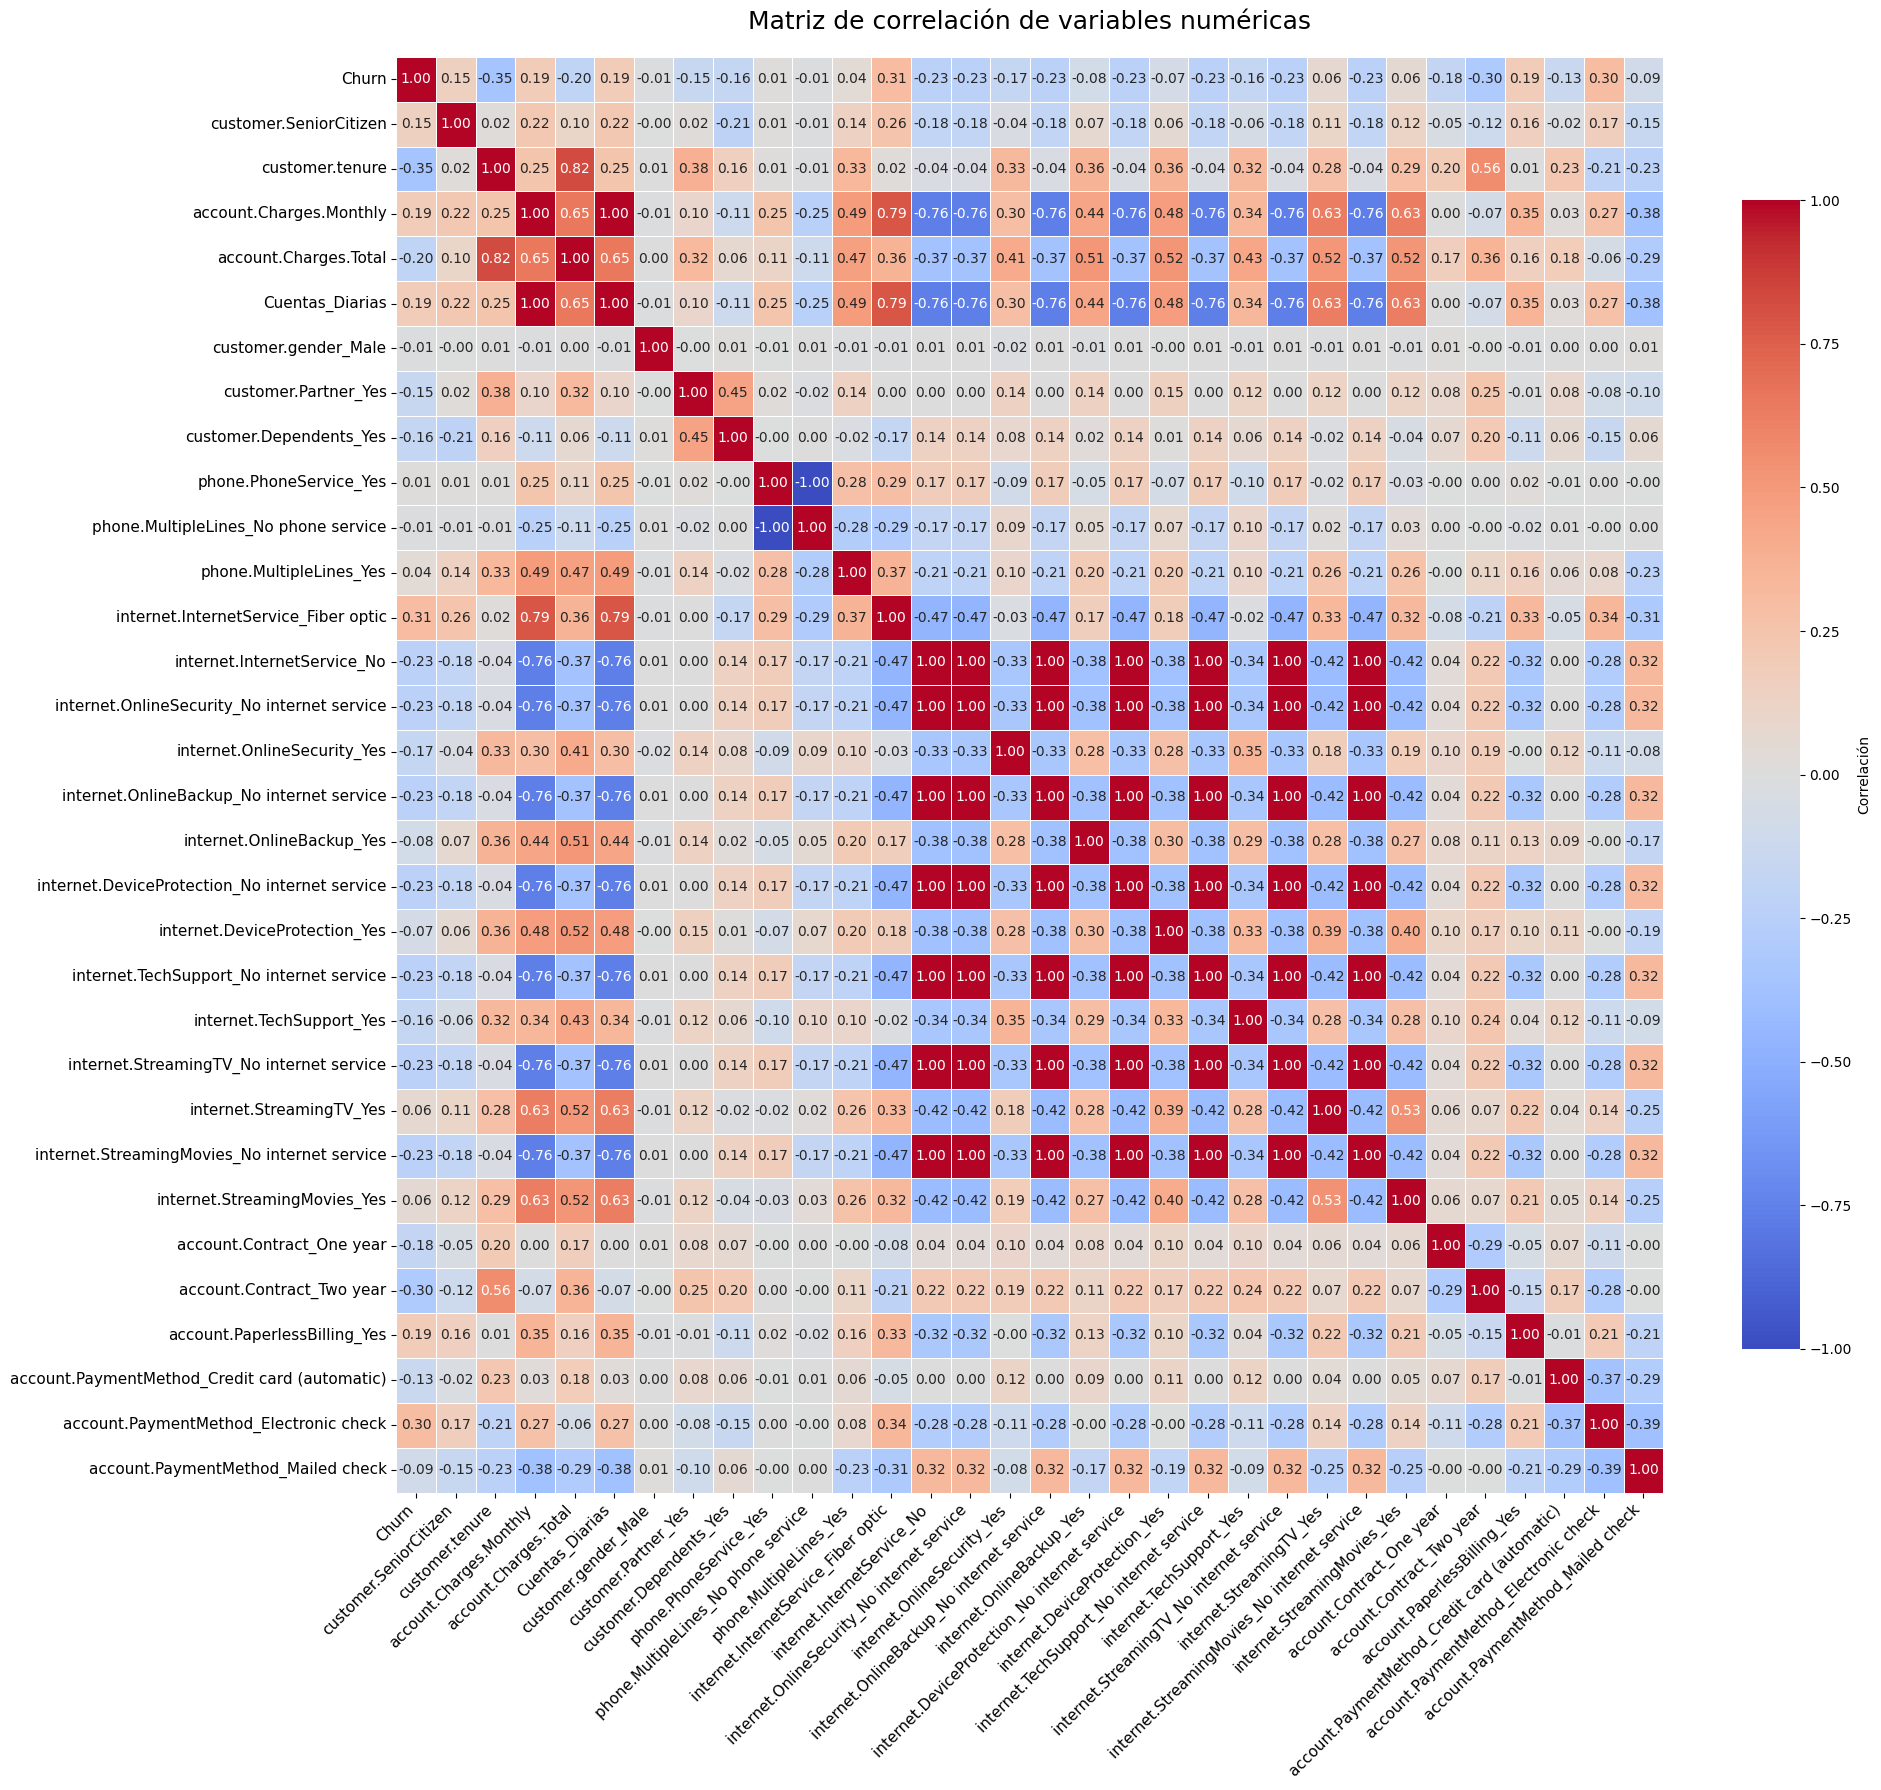

In [115]:
# Calcular matriz de correlación.
corr_matrix = df_model.corr()

plt.figure(figsize=(20,18))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.6,
    annot_kws={"size":10},
    cbar_kws={"shrink":0.8, "label":"Correlación"}
)

plt.title("Matriz de correlación de variables numéricas", fontsize=18, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

/tmp/ipykernel_166/2176197965.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_churn.values, y=corr_churn.index, palette=colors)


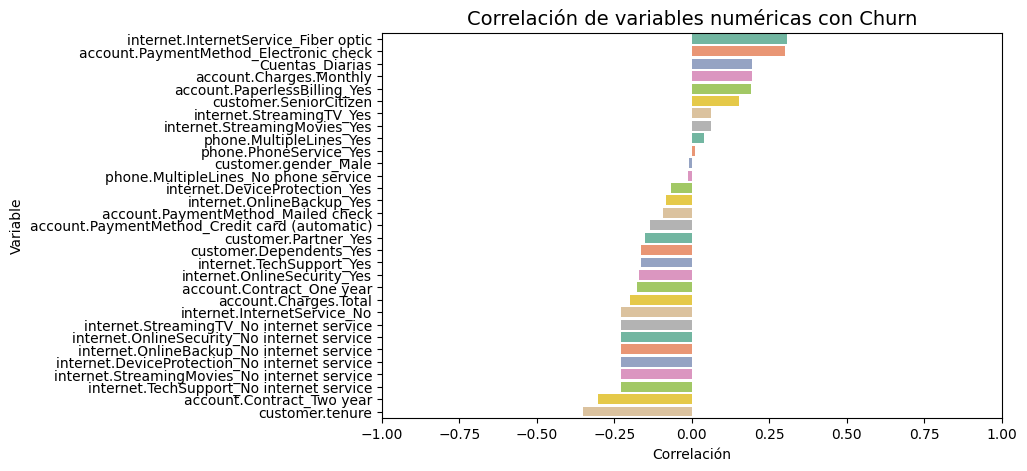

In [116]:
# Correlación con Churn en gráfico de barras (colores individuales).
corr_churn = df_model.corr()["Churn"].drop("Churn").sort_values(ascending=False)
colors = sns.color_palette("Set2", len(corr_churn))

plt.figure(figsize=(8,5))
sns.barplot(x=corr_churn.values, y=corr_churn.index, palette=colors)
plt.title("Correlación de variables numéricas con Churn", fontsize=14)
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.xlim(-1,1)
plt.show()


In [117]:
# Verificar.
df_model.head()

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,-0.439916,-0.951682,0.027862,-0.746190,0.027862,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,-0.439916,-0.951682,-0.161583,-0.768664,-0.161583,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,-0.439916,-1.155283,0.303720,-0.884147,0.303720,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,2.273159,-0.788800,1.104706,-0.461600,1.104706,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,2.273159,-1.196004,0.636080,-0.890085,0.636080,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


# Distribución de variables clave frente a Churn.

In [118]:
# Variables numéricas más relevantes: tenure y Charges.Total
plt.figure(figsize=(12,5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

/tmp/ipykernel_166/1899425954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


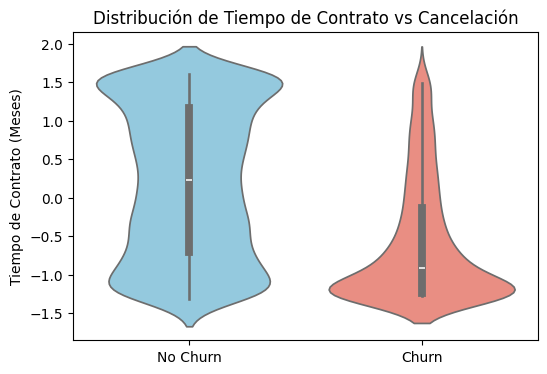

In [119]:
# Tiempo de contrato vs Churn.
colors = ["skyblue", "salmon"]  # 0 -> No Churn, 1 -> Churn

plt.figure(figsize=(6,4))
sns.violinplot(
    x="Churn",
    y="customer.tenure",
    data=df_model,
    palette=["skyblue","salmon"]
)

plt.xticks([0,1], ["No Churn","Churn"])
plt.xlabel("")
plt.ylabel("Tiempo de Contrato (Meses)")
plt.title("Distribución de Tiempo de Contrato vs Cancelación")
plt.show()

/tmp/ipykernel_166/3303955785.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


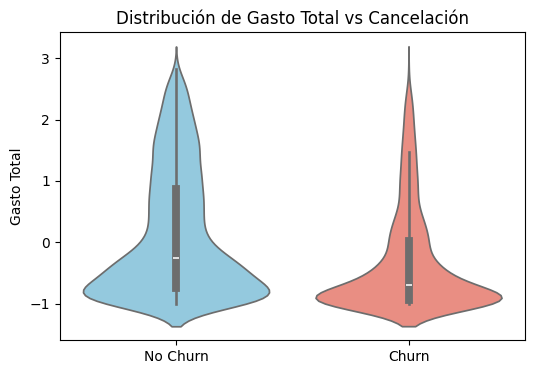

In [120]:
# Gasto total vs Churn.
colors = ["skyblue", "salmon"]  # primer valor → No Churn, segundo → Churn

plt.figure(figsize=(6,4))
sns.violinplot(
    x="Churn",
    y="account.Charges.Total",
    data=df_model,
    palette=colors
)

plt.xticks([0,1], ["No Churn","Churn"])  # etiquetas amigables
plt.xlabel("")
plt.ylabel("Gasto Total")
plt.title("Distribución de Gasto Total vs Cancelación")
plt.show()


# Separación de datos en entrenamiento y prueba.


In [121]:
# Variables independientes y objetivo.
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]


In [122]:
# División 70% entrenamiento, 30% prueba.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)



# Entrenamiento de modelos.


In [123]:
# Modelo 1: Regresión Logística (normalización importante).
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [124]:
# Modelo 2: Random Forest (no requiere normalización).
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


# Evaluación de modelos.


In [125]:
# Función para métricas.
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    print(f"--- {nombre_modelo} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred),3))
    print("Precision:", round(precision_score(y_true, y_pred),3))
    print("Recall:", round(recall_score(y_true, y_pred),3))
    print("F1-score:", round(f1_score(y_true, y_pred),3))
    print("Matriz de confusión:\n", confusion_matrix(y_true, y_pred))
    print("\n")

evaluar_modelo(y_test, y_pred_lr, "Regresión Logística")
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

--- Regresión Logística ---
Accuracy: 0.797
Precision: 0.639
Recall: 0.544
F1-score: 0.588
Matriz de confusión:
 [[1380  172]
 [ 256  305]]


--- Random Forest ---
Accuracy: 0.784
Precision: 0.617
Recall: 0.494
F1-score: 0.549
Matriz de confusión:
 [[1380  172]
 [ 284  277]]




/tmp/ipykernel_166/2537313693.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importancia", y="Variable", data=feat_importance_df, palette="magma")


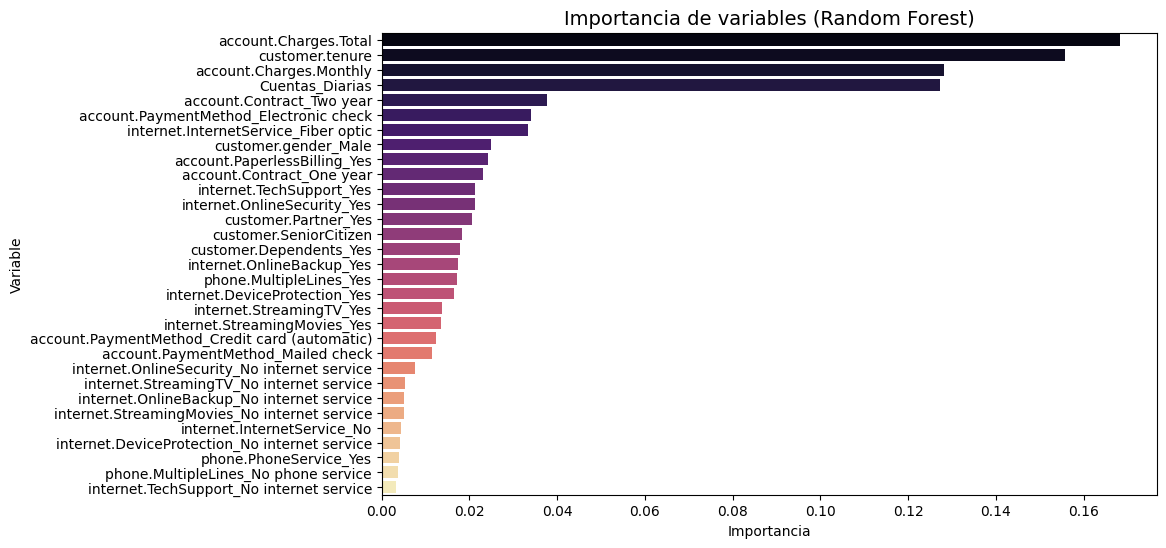

In [126]:
# Importancia de variables (Random Forest).

importances = rf.feature_importances_
feat_names = X.columns
feat_importance_df = pd.DataFrame({"Variable": feat_names, "Importancia": importances}).sort_values(by="Importancia", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importancia", y="Variable", data=feat_importance_df, palette="magma")
plt.title("Importancia de variables (Random Forest)", fontsize=14)
plt.show()


# Conclusiones.

- Los clientes nuevos y con bajo gasto total tienen mayor riesgo de cancelar.

- Las variables más relevantes para predecir Churn son: customer.tenure, account.Charges.Total, tipo de contrato y método de pago.

- Estrategia: implementar programas de retención y beneficios para clientes recientes o de bajo gasto, priorizando contratos mensuales y métodos de pago electrónicos.

- Modelos combinados (Logística + Random Forest) permiten predecir con buena precisión y orientar decisiones estratégicas.